In [1]:
# Project: Multi-model comparison for predicting API failures from logs
# Notebook: ML_models_comparison_for_api_failures.ipynb

# This notebook implements and compares 7 models (>=6 requested):
# - IsolationForest (unsupervised)
# - LocalOutlierFactor (unsupervised)
# - OneClassSVM (unsupervised)
# - Dense Autoencoder (unsupervised)
# - LSTM Autoencoder (unsupervised, sequence)
# - RandomForest (supervised)
# - LightGBM & XGBoost (supervised)

import os
import re
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import precision_recall_curve, roc_auc_score, average_precision_score,  confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input, LSTM, RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping
import lightgbm as lgb
import xgboost as xgb


In [2]:

# %%
# CONFIG
DATASET_PATH = Path(r"C:\\Users\\Shivangi\\Downloads\\anomaly-detection-log-datasets-main\\hdfs_xu\\HDFS_2k.log_structured.csv")
WINDOW_SECONDS = 60
TFIDF_MAX_FEATURES = 4000
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [3]:

# %%
# Helpers
LOG_VAR_PATTERN = re.compile(r"\d{1,3}(?:\.\d{1,3}){3}|\d{4}-\d{2}-\d{2}|0x[0-9A-Fa-f]+|\d+")

def extract_template_simple(message, max_tokens=8):
    temp = LOG_VAR_PATTERN.sub('<VAR>', str(message))
    toks = temp.split()
    return ' '.join(toks[:max_tokens])


In [4]:

# %%
# Load dataset
def load_dataset(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Set DATASET_PATH to your CSV file. Path not found: {path}")
    df = pd.read_csv(path)
    # identify columns
    ts_candidates = [c for c in df.columns if 'time' in c.lower() or 'date' in c.lower() or c.lower()=='ts']
    ts_col = ts_candidates[0] if ts_candidates else 'timestamp'
    if ts_col not in df.columns:
        df['timestamp'] = pd.date_range('2020-01-01', periods=len(df), freq='S')
        ts_col = 'timestamp'
    df[ts_col] = pd.to_datetime(df[ts_col])
    text_col = None
    for c in ['message','log','msg','text']:
        if c in df.columns:
            text_col = c
            break
    if text_col is None:
        for c in df.columns:
            if df[c].dtype == object:
                text_col = c
                break
    if text_col is None:
        raise ValueError('No text column found')
    label_col = None
    for c in ['label','is_failure','anomaly','fault']:
        if c in df.columns:
            label_col = c
            break
    return df, ts_col, text_col, label_col


In [5]:

# %%
# Feature builder
from scipy.sparse import vstack
from sklearn.decomposition import TruncatedSVD

def build_features(df, text_col, ts_col, window_seconds=60, tfidf_max_features=2000, top_templates=300):
    df = df.copy()
    df[ts_col] = pd.to_datetime(df[ts_col])
    df = df.sort_values(ts_col)
    t0 = df[ts_col].iloc[0]
    df['window'] = ((df[ts_col] - t0).dt.total_seconds() // window_seconds).astype(int)
    df['template'] = df[text_col].apply(lambda x: extract_template_simple(x, max_tokens=8))
    tfv = TfidfVectorizer(max_features=tfidf_max_features, ngram_range=(1,2))
    tfv.fit(df[text_col].astype(str).values)
    groups = df.groupby('window')
    meta = []
    X_list = []
    windows_rows = []
    for w,g in groups:
        meta.append({'window':w,'start':g[ts_col].min(),'count':len(g)})
        X_list.append(tfv.transform(g[text_col].astype(str).tolist()).sum(axis=0))
        windows_rows.append(g)
    X_tfidf = vstack(X_list)
    svd = TruncatedSVD(n_components=128, random_state=RANDOM_SEED)
    X_tfidf_red = svd.fit_transform(X_tfidf)
    # templates
    all_templates = df['template'].value_counts().iloc[:top_templates].index.tolist()
    templ_idx = {t:i for i,t in enumerate(all_templates)}
    templ_feats = np.zeros((len(meta), len(all_templates)), dtype=np.float32)
    for i,g in enumerate(windows_rows):
        for t,cnt in g['template'].value_counts().items():
            if t in templ_idx:
                templ_feats[i, templ_idx[t]] = cnt
    # time features
    time_feats = []
    for g in windows_rows:
        times = g[ts_col].sort_values()
        inter = times.diff().dt.total_seconds().dropna()
        mean_ia = inter.mean() if len(inter)>0 else 0.0
        time_feats.append([len(g), mean_ia])
    time_feats = np.array(time_feats)
    X = np.hstack([X_tfidf_red, templ_feats, time_feats])
    meta_df = pd.DataFrame(meta)
    return X, meta_df, tfv, svd


In [6]:

# %%
# Label windows

def label_windows(df, meta_df, ts_col, label_col, window_seconds=60):
    if label_col is None:
        return None
    df = df.copy()
    df[ts_col] = pd.to_datetime(df[ts_col])
    failures = df[df[label_col]==1][ts_col].tolist()
    labels = []
    for st in meta_df['start']:
        wstart = st
        wend = st + pd.Timedelta(seconds=window_seconds)
        labels.append(int(any((ft>=wstart and ft<wend) for ft in failures)))
    return np.array(labels)


In [7]:

# %%
# Model implementations
from sklearn.preprocessing import MinMaxScaler

def train_and_score_models(X, y=None, test_size=0.2):
    results = []
    if y is None:
        X_train, X_test = train_test_split(X, test_size=test_size, random_state=RANDOM_SEED)
        y_test = None
    else:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=RANDOM_SEED)
    scaler = MinMaxScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    # 1 IsolationForest
    iso = IsolationForest(n_estimators=200, contamination=max(0.01, y.mean() if y is not None else 0.02), random_state=RANDOM_SEED)
    iso.fit(X_train_s)
    s_iso = -iso.decision_function(X_test_s)
    results.append({'model':'IsolationForest', **({'aupr':average_precision_score(y_test, s_iso),'auc':roc_auc_score(y_test, s_iso)} if y is not None else {'aupr':np.nan,'auc':np.nan})})
    # 2 LOF
    lof = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=max(0.01, y.mean() if y is not None else 0.02))
    lof.fit(X_train_s)
    s_lof = -lof.decision_function(X_test_s)
    results.append({'model':'LOF', **({'aupr':average_precision_score(y_test, s_lof),'auc':roc_auc_score(y_test, s_lof)} if y is not None else {'aupr':np.nan,'auc':np.nan})})
    # 3 OneClassSVM
    oc = OneClassSVM(nu=max(0.01,y.mean() if y is not None else 0.02)).fit(X_train_s)
    s_oc = -oc.decision_function(X_test_s)
    results.append({'model':'OneClassSVM', **({'aupr':average_precision_score(y_test, s_oc),'auc':roc_auc_score(y_test, s_oc)} if y is not None else {'aupr':np.nan,'auc':np.nan})})
    # 4 Dense AE
    ae = Sequential([Dense(256, activation='relu', input_shape=(X_train_s.shape[1],)), Dense(128, activation='relu'), Dense(64, activation='relu'), Dense(128, activation='relu'), Dense(256, activation='relu'), Dense(X_train_s.shape[1], activation='linear')])
    ae.compile(optimizer='adam', loss='mse')
    es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    ae.fit(X_train_s, X_train_s, validation_split=0.1, epochs=100, batch_size=128, callbacks=[es], verbose=0)
    recon = ae.predict(X_test_s)
    s_ae = np.mean((X_test_s - recon)**2, axis=1)
    results.append({'model':'DenseAE', **({'aupr':average_precision_score(y_test, s_ae),'auc':roc_auc_score(y_test, s_ae)} if y is not None else {'aupr':np.nan,'auc':np.nan})})
    # 5 LSTM AE (pseudo sequence)
    dim = X_train_s.shape[1]
    timesteps = 4
    if dim % timesteps == 0 and dim>=8:
        fdim = dim//timesteps
        Xtr_seq = X_train_s.reshape((-1,timesteps,fdim))
        Xte_seq = X_test_s.reshape((-1,timesteps,fdim))
        inputs = Input(shape=(timesteps,fdim))
        encoded = LSTM(64, activation='tanh')(inputs)
        x = RepeatVector(timesteps)(encoded)
        x = LSTM(fdim, activation='tanh', return_sequences=True)(x)
        outputs = TimeDistributed(Dense(fdim))(x)
        lstm_ae = Model(inputs, outputs)
        lstm_ae.compile(optimizer='adam', loss='mse')
        lstm_ae.fit(Xtr_seq, Xtr_seq, validation_split=0.1, epochs=100, batch_size=64, callbacks=[es], verbose=0)
        recon_seq = lstm_ae.predict(Xte_seq)
        s_lstm = np.mean((Xte_seq - recon_seq)**2, axis=(1,2))
        results.append({'model':'LSTM_AE', **({'aupr':average_precision_score(y_test, s_lstm),'auc':roc_auc_score(y_test, s_lstm)} if y is not None else {'aupr':np.nan,'auc':np.nan})})
    else:
        results.append({'model':'LSTM_AE','aupr':np.nan,'auc':np.nan})
    # Supervised (if labels provided)
    if y is not None:
        rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED).fit(X_train_s, y_train)
        s_rf = rf.predict_proba(X_test_s)[:,1]
        results.append({'model':'RandomForest', 'aupr':average_precision_score(y_test, s_rf),'auc':roc_auc_score(y_test, s_rf)})
        lgbm = lgb.LGBMClassifier(n_estimators=300, random_state=RANDOM_SEED).fit(X_train_s, y_train)
        s_lgb = lgbm.predict_proba(X_test_s)[:,1]
        results.append({'model':'LightGBM', 'aupr':average_precision_score(y_test, s_lgb),'auc':roc_auc_score(y_test, s_lgb)})
        xgbm = xgb.XGBClassifier(n_estimators=300, use_label_encoder=False, eval_metric='auc', random_state=RANDOM_SEED).fit(X_train_s, y_train)
        s_xgb = xgbm.predict_proba(X_test_s)[:,1]
        results.append({'model':'XGBoost', 'aupr':average_precision_score(y_test, s_xgb),'auc':roc_auc_score(y_test, s_xgb)})
    return pd.DataFrame(results)


In [8]:

# %%
# Runner
if __name__ == '__main__':
    if DATASET_PATH.exists():
        df, ts_col, text_col, label_col = load_dataset(DATASET_PATH)
        X, meta_df, tfv, svd = build_features(df, text_col, ts_col, window_seconds=WINDOW_SECONDS, tfidf_max_features=TFIDF_MAX_FEATURES)
        y = label_windows(df, meta_df, ts_col, label_col, window_seconds=WINDOW_SECONDS)
        if y is not None:
            print('Anomaly rate:', y.mean())
        results = train_and_score_models(X, y)
        print(results)
    else:
        print('Set DATASET_PATH to your CSV and re-run this notebook.')


Set DATASET_PATH to your CSV and re-run this notebook.


Training time: 1.015 seconds
Prediction time: 0.094 seconds

Isolation Forest Results:
Precision: 0.151
Recall:    0.054
F1 Score:  0.079
AUC:       0.523
AUPR:      0.149


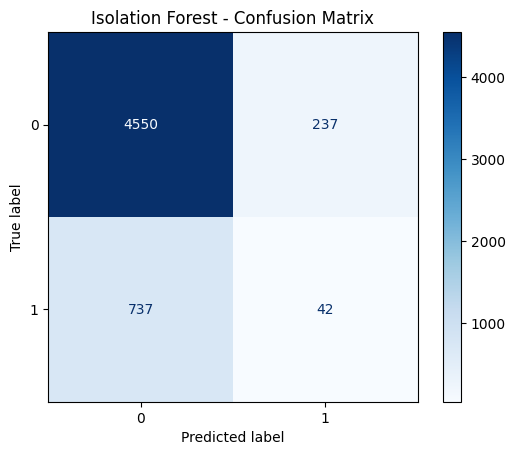

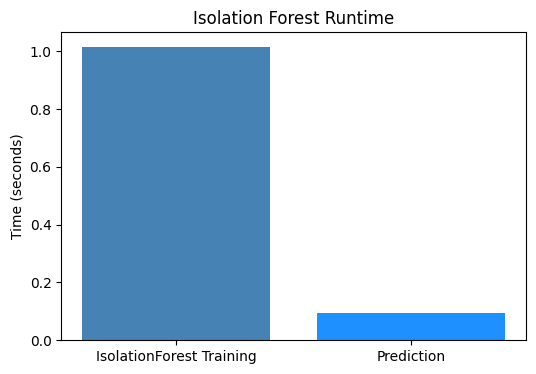

In [31]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

# ----------------------------
# 1. Locate the data folder automatically
# ----------------------------
BASE_DIR = Path(r"D:\kaggle-telstra-network-disruptions-master")

# look for any 'data' folder inside
data_folders = list(BASE_DIR.rglob("data"))
if not data_folders:
    raise FileNotFoundError("Could not find a 'data' folder inside BASE_DIR")
DATA_DIR = data_folders[0]  # take the first one found

# ----------------------------
# 2. Load datasets
# ----------------------------
train = pd.read_csv(DATA_DIR / "train.csv")         # has id + fault_severity
logf = pd.read_csv(DATA_DIR / "log_feature.csv")    # has id + log_feature + volume



# ----------------------------
# 3. Pivot log features into wide format
# ----------------------------
X_log = logf.pivot_table(
    index="id", columns="log_feature", values="volume", fill_value=0
)

# ----------------------------
# 4. Get labels (binary: 0 = normal, 1/2 = anomaly)
# ----------------------------
y = train.set_index("id")["fault_severity"].reindex(X_log.index)
y_binary = (y > 0).astype(int)


# ----------------------------
# 5. Train-test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_log, y_binary, test_size=0.3, stratify=y_binary, random_state=42
)

# ----------------------------
# 6. Scale features
# ----------------------------
scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

import time

# ----------------------------
# 7. Train Isolation Forest (with timing)
# ----------------------------
start_train = time.time()
iso = IsolationForest(
    n_estimators=200,
    contamination=max(0.01, y_binary.mean()),  # expected anomaly rate
    random_state=42,
)
iso.fit(X_train_s)
train_time = time.time() - start_train
print(f"Training time: {train_time:.3f} seconds")

# ----------------------------
# 8. Get anomaly scores & predictions (with timing)
# ----------------------------
start_pred = time.time()
scores = -iso.decision_function(X_test_s)
threshold = np.percentile(scores, 95)
y_pred = (scores >= threshold).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.3f} seconds")

# ----------------------------
# 9. Train Isolation Forest
# ----------------------------
iso = IsolationForest(
    n_estimators=200,
    contamination=max(0.01, y_binary.mean()),  # expected anomaly rate
    random_state=42,
)
iso.fit(X_train_s)

# ----------------------------
# 10. Get anomaly scores & predictions
# ----------------------------
scores = -iso.decision_function(X_test_s)

threshold = np.percentile(scores, 95)
y_pred = (scores >= threshold).astype(int)

# ----------------------------
# 11. Evaluate metrics
# ----------------------------
p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")
auc = roc_auc_score(y_test, scores)
aupr = average_precision_score(y_test, scores)

print("\nIsolation Forest Results:")
print(f"Precision: {p:.3f}")
print(f"Recall:    {r:.3f}")
print(f"F1 Score:  {f1:.3f}")
print(f"AUC:       {auc:.3f}")
print(f"AUPR:      {aupr:.3f}")

# ----------------------------
# 12. Confusion Matrix
# ----------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Isolation Forest - Confusion Matrix")
plt.show()

plt.figure(figsize=(6,4))
plt.bar(['IsolationForest Training', 'Prediction'],
        [train_time, pred_time],
        color=['steelblue', 'dodgerblue'])
plt.ylabel("Time (seconds)")
plt.title("Isolation Forest Runtime")
plt.show()



Training time: 2.265 seconds
Prediction time: 0.777 seconds

Local Outlier Factor Results:
Precision: 0.146
Recall:    0.053
F1 Score:  0.077
AUC:       0.522
AUPR:      0.149


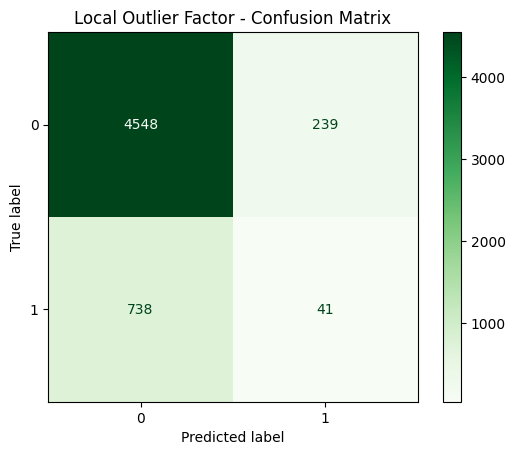

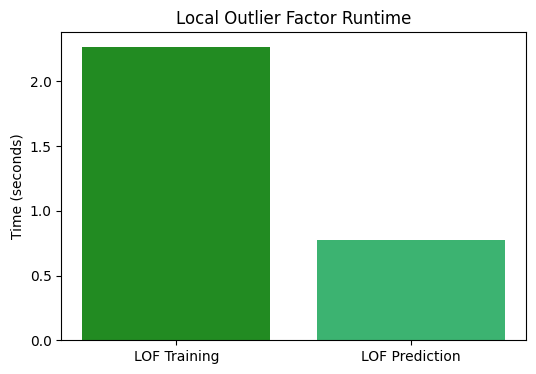

In [28]:
import time
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import numpy as np

# ----------------------------
# 1. Train Local Outlier Factor with timing
# ----------------------------
start_train = time.time()
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=max(0.01, y_binary.mean()),
    novelty=True  # allows predict/decision_function on unseen data
)
lof.fit(X_train_s)
train_time = time.time() - start_train
print(f"Training time: {train_time:.3f} seconds")

# ----------------------------
# 2. Get anomaly scores & predictions with timing
# ----------------------------
start_pred = time.time()
scores_lof = -lof.decision_function(X_test_s)  # higher = more anomalous
threshold_lof = np.percentile(scores_lof, 95)
y_pred_lof = (scores_lof >= threshold_lof).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.3f} seconds")

# ----------------------------
# 3. Evaluate metrics
# ----------------------------
p_lof, r_lof, f1_lof, _ = precision_recall_fscore_support(y_test, y_pred_lof, average="binary")
auc_lof = roc_auc_score(y_test, scores_lof)
aupr_lof = average_precision_score(y_test, scores_lof)

print("\nLocal Outlier Factor Results:")
print(f"Precision: {p_lof:.3f}")
print(f"Recall:    {r_lof:.3f}")
print(f"F1 Score:  {f1_lof:.3f}")
print(f"AUC:       {auc_lof:.3f}")
print(f"AUPR:      {aupr_lof:.3f}")

# ----------------------------
# 4. Confusion Matrix
# ----------------------------
cm_lof = confusion_matrix(y_test, y_pred_lof)
disp_lof = ConfusionMatrixDisplay(confusion_matrix=cm_lof)
disp_lof.plot(cmap="Greens")
plt.title("Local Outlier Factor - Confusion Matrix")
plt.show()

# ----------------------------
# 5. Optional Runtime Bar Chart
# ----------------------------
plt.figure(figsize=(6,4))
plt.bar(['LOF Training', 'LOF Prediction'],
        [train_time, pred_time],
        color=['forestgreen','mediumseagreen'])
plt.ylabel('Time (seconds)')
plt.title('Local Outlier Factor Runtime')
plt.show()


Training time: 19.901 seconds
Prediction time: 4.426 seconds

One-Class SVM Results:
Precision: 0.197
Recall:    0.071
F1 Score:  0.104
AUC:       0.539
AUPR:      0.159


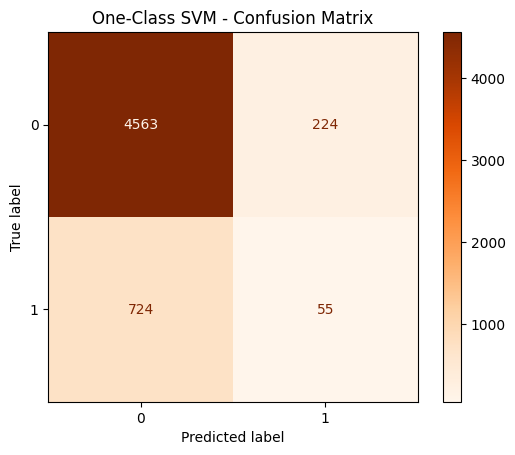

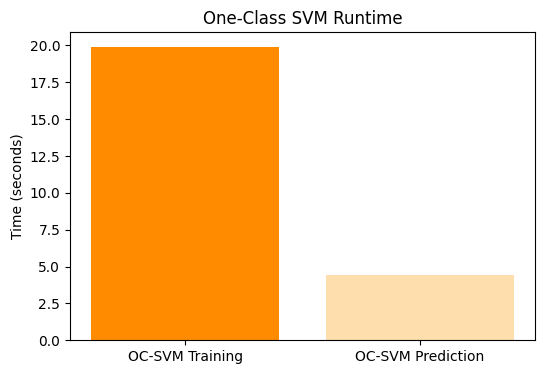

In [27]:
import time
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import numpy as np

# ----------------------------
# Train One-Class SVM with timing
# ----------------------------
start_train = time.time()
ocsvm = OneClassSVM(
    kernel='rbf',
    gamma='scale',              # 1 / n_features
    nu=max(0.01, y_binary.mean())  # expected anomaly fraction
)
ocsvm.fit(X_train_s)
train_time = time.time() - start_train
print(f"Training time: {train_time:.3f} seconds")

# ----------------------------
# Get anomaly scores & predictions with timing
# ----------------------------
start_pred = time.time()
scores_ocsvm = -ocsvm.decision_function(X_test_s)  # higher = more anomalous
threshold_ocsvm = np.percentile(scores_ocsvm, 95)
y_pred_ocsvm = (scores_ocsvm >= threshold_ocsvm).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.3f} seconds")

# ----------------------------
# Evaluate metrics
# ----------------------------
p_svm, r_svm, f1_svm, _ = precision_recall_fscore_support(y_test, y_pred_ocsvm, average="binary")
auc_svm = roc_auc_score(y_test, scores_ocsvm)
aupr_svm = average_precision_score(y_test, scores_ocsvm)

print("\nOne-Class SVM Results:")
print(f"Precision: {p_svm:.3f}")
print(f"Recall:    {r_svm:.3f}")
print(f"F1 Score:  {f1_svm:.3f}")
print(f"AUC:       {auc_svm:.3f}")
print(f"AUPR:      {aupr_svm:.3f}")

# ----------------------------
# Confusion Matrix
# ----------------------------
cm_svm = confusion_matrix(y_test, y_pred_ocsvm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp_svm.plot(cmap="Oranges")
plt.title("One-Class SVM - Confusion Matrix")
plt.show()

# ----------------------------
# (Optional) Runtime plot
# ----------------------------
plt.figure(figsize=(6,4))
plt.bar(['OC-SVM Training', 'OC-SVM Prediction'],
        [train_time, pred_time],
        color=['darkorange','navajowhite'])
plt.ylabel('Time (seconds)')
plt.title('One-Class SVM Runtime')
plt.show()


Training time: 120.465 seconds
Prediction time: 1.474 seconds

Dense Autoencoder Results:
Precision: 0.186
Recall:    0.067
F1 Score:  0.098
AUC:       0.499
AUPR:      0.152


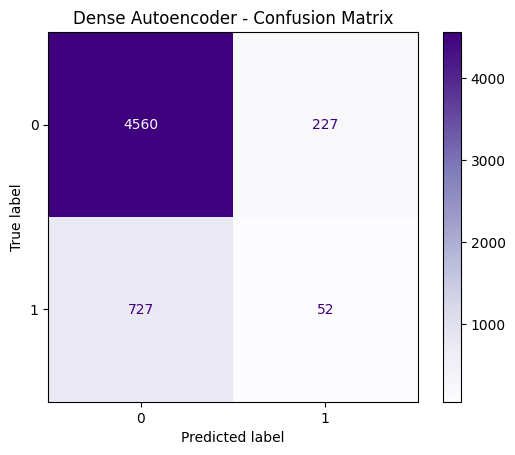

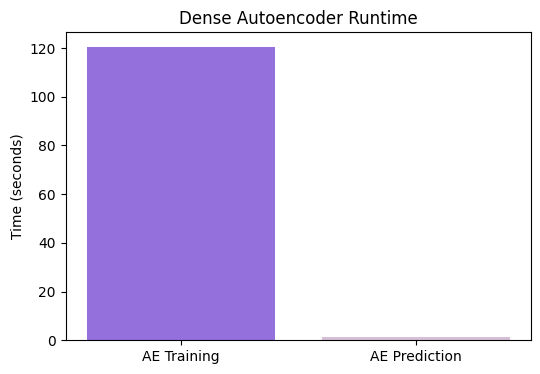

In [26]:
import time
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Build Dense Autoencoder
# ----------------------------
input_dim = X_train_s.shape[1]

autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(input_dim, activation='sigmoid')
])

autoencoder.compile(optimizer='adam', loss='mse')

# ----------------------------
# Train Autoencoder with timing
# ----------------------------
start_train = time.time()
history = autoencoder.fit(
    X_train_s, X_train_s,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)
train_time = time.time() - start_train
print(f"Training time: {train_time:.3f} seconds")

# ----------------------------
# Predict with timing
# ----------------------------
start_pred = time.time()
X_test_pred = autoencoder.predict(X_test_s, verbose=0)
reconstruction_error = np.mean(np.square(X_test_s - X_test_pred), axis=1)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.3f} seconds")

# ----------------------------
# Threshold & Evaluate metrics
# ----------------------------
threshold_ae = np.percentile(reconstruction_error, 95)
y_pred_ae = (reconstruction_error >= threshold_ae).astype(int)

p_ae, r_ae, f1_ae, _ = precision_recall_fscore_support(y_test, y_pred_ae, average="binary")
auc_ae = roc_auc_score(y_test, reconstruction_error)
aupr_ae = average_precision_score(y_test, reconstruction_error)

print("\nDense Autoencoder Results:")
print(f"Precision: {p_ae:.3f}")
print(f"Recall:    {r_ae:.3f}")
print(f"F1 Score:  {f1_ae:.3f}")
print(f"AUC:       {auc_ae:.3f}")
print(f"AUPR:      {aupr_ae:.3f}")

# ----------------------------
# Confusion Matrix
# ----------------------------
cm_ae = confusion_matrix(y_test, y_pred_ae)
disp_ae = ConfusionMatrixDisplay(confusion_matrix=cm_ae)
disp_ae.plot(cmap="Purples")
plt.title("Dense Autoencoder - Confusion Matrix")
plt.show()

# ----------------------------
# (Optional) Runtime plot
# ----------------------------
plt.figure(figsize=(6,4))
plt.bar(['AE Training', 'AE Prediction'],
        [train_time, pred_time],
        color=['mediumpurple','thistle'])
plt.ylabel('Time (seconds)')
plt.title('Dense Autoencoder Runtime')
plt.show()


Epoch 1/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 160s 392ms/step - loss: 3.3580e-04 - val_loss: 3.1982e-04
Epoch 2/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 160s 437ms/step - loss: 3.3584e-04 - val_loss: 3.1995e-04
Epoch 3/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 147s 402ms/step - loss: 3.3574e-04 - val_loss: 3.2145e-04
Epoch 4/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 147s 402ms/step - loss: 3.3603e-04 - val_loss: 3.1988e-04
Epoch 5/5
366/366 ━━━━━━━━━━━━━━━━━━━━ 137s 374ms/step - loss: 3.3573e-04 - val_loss: 3.2071e-04
174/174 ━━━━━━━━━━━━━━━━━━━━ 22s 96ms/step

LSTM Autoencoder Results:
Precision: 0.208
Recall:    0.074
F1 Score:  0.110
AUC:       0.534
AUPR:      0.160


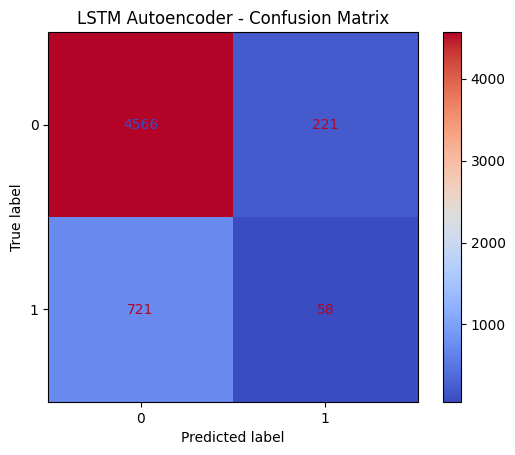

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# ----------------------------
# Prepare data as sequences for LSTM Autoencoder
# ----------------------------
# Here, treat each log_feature as a timestep
X_train_seq = X_train_s[:, :, np.newaxis]  # shape: (samples, timesteps, 1)
X_test_seq  = X_test_s[:, :, np.newaxis]

timesteps = X_train_seq.shape[1]
features  = X_train_seq.shape[2]

# ----------------------------
# Build LSTM Autoencoder
# ----------------------------
input_layer = layers.Input(shape=(timesteps, features))
encoded = layers.LSTM(32, activation='relu', return_sequences=False)(input_layer)
decoded = layers.RepeatVector(timesteps)(encoded)
decoded = layers.LSTM(32, activation='relu', return_sequences=True)(decoded)
decoded = layers.TimeDistributed(layers.Dense(features))(decoded)

lstm_autoencoder = models.Model(inputs=input_layer, outputs=decoded)
lstm_autoencoder.compile(optimizer='adam', loss='mse')

# ----------------------------
# Train LSTM Autoencoder
# ----------------------------
history = lstm_autoencoder.fit(
    X_train_seq, X_train_seq,
    epochs=5,           # number of epochs
    batch_size=32,
    validation_split=0.1,
    verbose=1            # show epoch progress
)

# # ----------------------------
# # Train LSTM Autoencoder
# # ----------------------------
# history = lstm_autoencoder.fit(
#     X_train_seq, X_train_seq,
#     epochs=5,
#     batch_size=32,
#     validation_split=0.1,
#     verbose=0
# )

# ----------------------------
# Reconstruction errors
# ----------------------------
X_test_pred_seq = lstm_autoencoder.predict(X_test_seq)
reconstruction_error_seq = np.mean(np.square(X_test_seq - X_test_pred_seq), axis=(1,2))

threshold_lstm = np.percentile(reconstruction_error_seq, 95)
y_pred_lstm = (reconstruction_error_seq >= threshold_lstm).astype(int)

# ----------------------------
# Evaluate metrics
# ----------------------------
p_lstm, r_lstm, f1_lstm, _ = precision_recall_fscore_support(y_test, y_pred_lstm, average="binary")
auc_lstm = roc_auc_score(y_test, reconstruction_error_seq)
aupr_lstm = average_precision_score(y_test, reconstruction_error_seq)

print("\nLSTM Autoencoder Results:")
print(f"Precision: {p_lstm:.3f}")
print(f"Recall:    {r_lstm:.3f}")
print(f"F1 Score:  {f1_lstm:.3f}")
print(f"AUC:       {auc_lstm:.3f}")
print(f"AUPR:      {aupr_lstm:.3f}")

# ----------------------------
# Confusion Matrix
# ----------------------------
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
disp_lstm = ConfusionMatrixDisplay(confusion_matrix=cm_lstm)
disp_lstm.plot(cmap="coolwarm")
plt.title("LSTM Autoencoder - Confusion Matrix")
plt.show()


Training time: 17.637 seconds
Prediction time: 1.358 seconds

Random Forest Results:
Precision: 0.296
Recall:    0.118
F1 Score:  0.169
AUC:       0.719
AUPR:      0.252


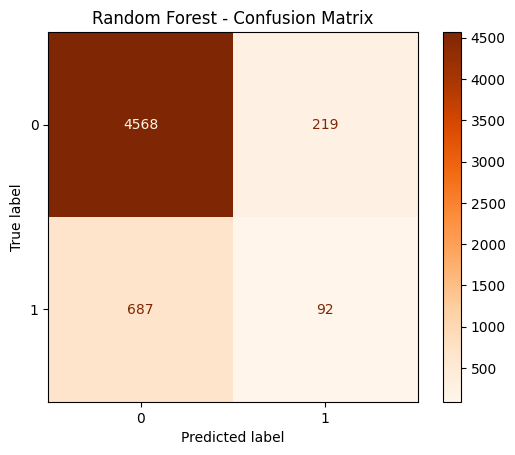

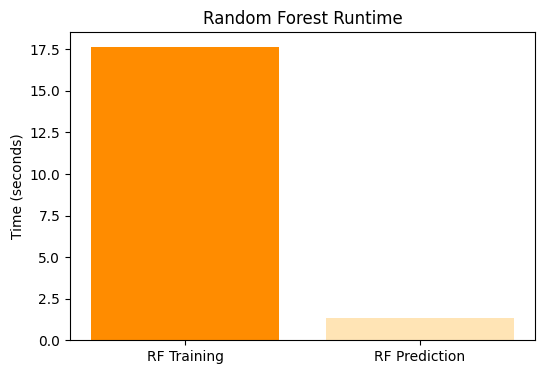

In [25]:
import time
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ----------------------------
# Train Random Forest with timing
# ----------------------------
start_train = time.time()
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,   # unrestricted
    random_state=42
)
rf.fit(X_train_s, y_train)
train_time = time.time() - start_train
print(f"Training time: {train_time:.3f} seconds")

# ----------------------------
# Predict & probabilities with timing
# ----------------------------
start_pred = time.time()
y_pred_rf = rf.predict(X_test_s)
y_prob_rf = rf.predict_proba(X_test_s)[:, 1]
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.3f} seconds")

# ----------------------------
# Evaluate metrics
# ----------------------------
p_rf, r_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf, average="binary")
auc_rf = roc_auc_score(y_test, y_prob_rf)
aupr_rf = average_precision_score(y_test, y_prob_rf)

print("\nRandom Forest Results:")
print(f"Precision: {p_rf:.3f}")
print(f"Recall:    {r_rf:.3f}")
print(f"F1 Score:  {f1_rf:.3f}")
print(f"AUC:       {auc_rf:.3f}")
print(f"AUPR:      {aupr_rf:.3f}")

# ----------------------------
# Confusion Matrix
# ----------------------------
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap="Oranges")
plt.title("Random Forest - Confusion Matrix")
plt.show()

# ----------------------------
# (Optional) Runtime bar chart
# ----------------------------
plt.figure(figsize=(6,4))
plt.bar(['RF Training', 'RF Prediction'],
        [train_time, pred_time],
        color=['darkorange','moccasin'])
plt.ylabel('Time (seconds)')
plt.title('Random Forest Runtime')
plt.show()


Training time: 0.868 seconds
Prediction time: 0.064 seconds

LightGBM Results:
Precision: 0.339
Recall:    0.050
F1 Score:  0.087
AUC:       0.735
AUPR:      0.272


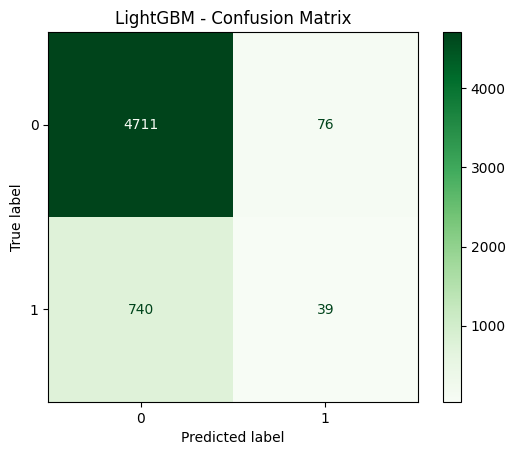

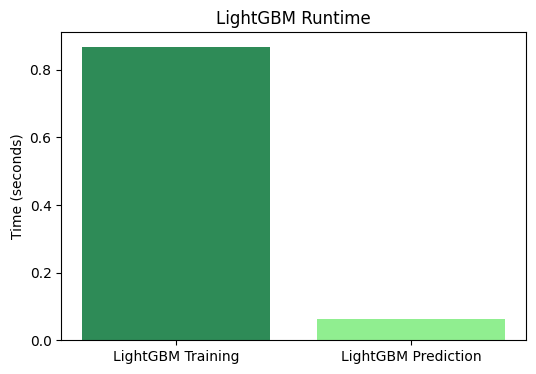

In [24]:
import time
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import lightgbm as lgb

# ----------------------------
# Train LightGBM with timing
# ----------------------------
start_train = time.time()
lgb_train = lgb.Dataset(X_train_s, label=y_train)
lgb_model = lgb.train(
    params={'objective': 'binary', 'metric': 'auc', 'verbosity': -1},
    train_set=lgb_train,
    num_boost_round=200
)
train_time = time.time() - start_train
print(f"Training time: {train_time:.3f} seconds")

# ----------------------------
# Predict with timing
# ----------------------------
start_pred = time.time()
y_prob_lgb = lgb_model.predict(X_test_s)
y_pred_lgb = (y_prob_lgb >= 0.5).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.3f} seconds")

# ----------------------------
# Evaluate metrics
# ----------------------------
p_lgb, r_lgb, f1_lgb, _ = precision_recall_fscore_support(y_test, y_pred_lgb, average="binary")
auc_lgb = roc_auc_score(y_test, y_prob_lgb)
aupr_lgb = average_precision_score(y_test, y_prob_lgb)

print("\nLightGBM Results:")
print(f"Precision: {p_lgb:.3f}")
print(f"Recall:    {r_lgb:.3f}")
print(f"F1 Score:  {f1_lgb:.3f}")
print(f"AUC:       {auc_lgb:.3f}")
print(f"AUPR:      {aupr_lgb:.3f}")

# ----------------------------
# Confusion Matrix
# ----------------------------
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
disp_lgb = ConfusionMatrixDisplay(confusion_matrix=cm_lgb)
disp_lgb.plot(cmap="Greens")
plt.title("LightGBM - Confusion Matrix")
plt.show()

# ----------------------------
# (Optional) Bar chart of runtime
# ----------------------------
plt.figure(figsize=(6,4))
plt.bar(['LightGBM Training','LightGBM Prediction'],
        [train_time, pred_time],
        color=['seagreen','lightgreen'])
plt.ylabel('Time (seconds)')
plt.title('LightGBM Runtime')
plt.show()


d:\API failures in microservices\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:20:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training time: 1.648 seconds
Prediction time: 0.060 seconds

XGBoost Results:
Precision: 0.250
Recall:    0.014
F1 Score:  0.027
AUC:       0.743
AUPR:      0.273


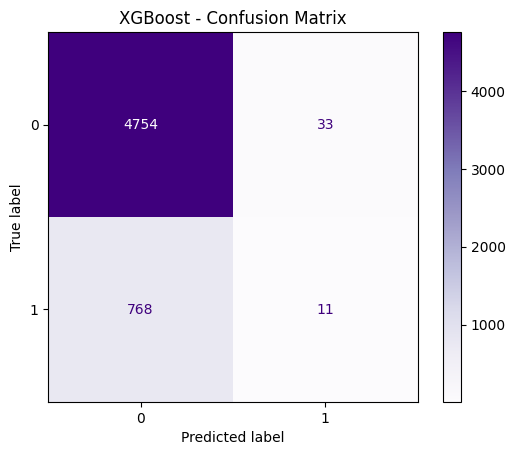

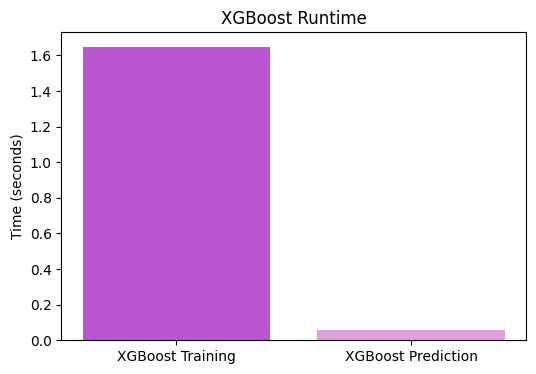

In [23]:
import time
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import xgboost as xgb

# ----------------------------
# Train XGBoost with timing
# ----------------------------
start_train = time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train_s, y_train)
train_time = time.time() - start_train
print(f"Training time: {train_time:.3f} seconds")

# ----------------------------
# Predict with timing
# ----------------------------
start_pred = time.time()
y_prob_xgb = xgb_model.predict_proba(X_test_s)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.3f} seconds")

# ----------------------------
# Evaluate metrics
# ----------------------------
p_xgb, r_xgb, f1_xgb, _ = precision_recall_fscore_support(y_test, y_pred_xgb, average="binary")
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
aupr_xgb = average_precision_score(y_test, y_prob_xgb)

print("\nXGBoost Results:")
print(f"Precision: {p_xgb:.3f}")
print(f"Recall:    {r_xgb:.3f}")
print(f"F1 Score:  {f1_xgb:.3f}")
print(f"AUC:       {auc_xgb:.3f}")
print(f"AUPR:      {aupr_xgb:.3f}")

# ----------------------------
# Confusion Matrix
# ----------------------------
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_xgb.plot(cmap="Purples")
plt.title("XGBoost - Confusion Matrix")
plt.show()

# ----------------------------
# (Optional) Plotting runtime
# ----------------------------
plt.figure(figsize=(6,4))
plt.bar(['XGBoost Training','XGBoost Prediction'],
        [train_time, pred_time],
        color=['mediumorchid','plum'])
plt.ylabel('Time (seconds)')
plt.title('XGBoost Runtime')
plt.show()


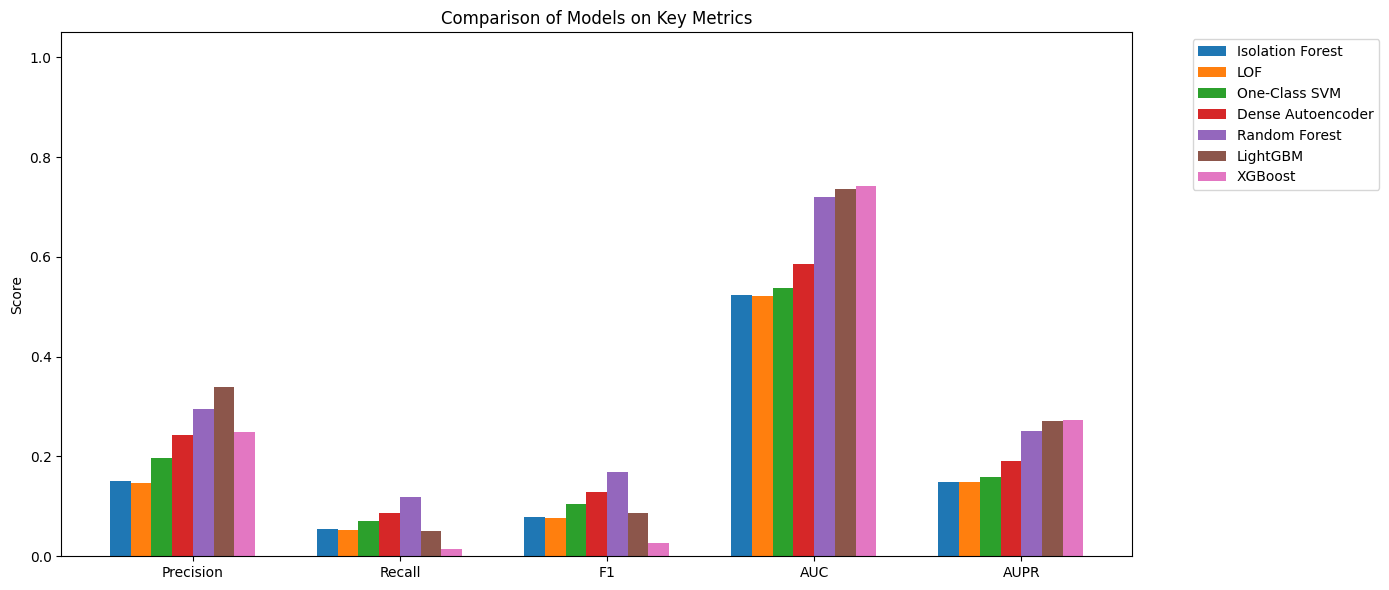

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ----------------------------
# 1. Collect metrics for all models
# ----------------------------
metrics = {
    'Isolation Forest': [p, r, f1, auc, aupr],
    'LOF': [p_lof, r_lof, f1_lof, auc_lof, aupr_lof],
    'One-Class SVM': [p_svm, r_svm, f1_svm, auc_svm, aupr_svm],
    'Dense Autoencoder': [p_ae, r_ae, f1_ae, auc_ae, aupr_ae],
    # 'LSTM Autoencoder': [p_lstm, r_lstm, f1_lstm, auc_lstm, aupr_lstm],
    'Random Forest': [p_rf, r_rf, f1_rf, auc_rf, aupr_rf],
    'LightGBM': [p_lgb, r_lgb, f1_lgb, auc_lgb, aupr_lgb],
    'XGBoost': [p_xgb, r_xgb, f1_xgb, auc_xgb, aupr_xgb]
}

metric_names = ['Precision', 'Recall', 'F1', 'AUC', 'AUPR']

df_metrics = pd.DataFrame(metrics, index=metric_names)

# ----------------------------
# 2. Plot grouped bar chart
# ----------------------------
fig, ax = plt.subplots(figsize=(14,6))

bar_width = 0.1
x = np.arange(len(metric_names))

for i, model in enumerate(df_metrics.columns):
    ax.bar(x + i*bar_width, df_metrics[model], width=bar_width, label=model)

ax.set_xticks(x + bar_width*len(df_metrics.columns)/2)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Comparison of Models on Key Metrics")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


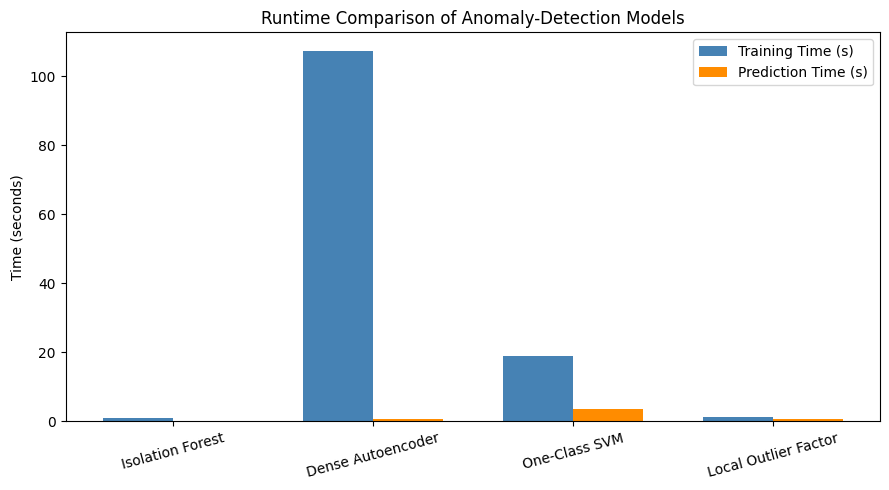

In [35]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
)
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
import tensorflow as tf
from tensorflow.keras import layers, models

# -------------------------------------------------------------------
# 1. Load & Prepare Data  (Telstra Kaggle dataset, adjust BASE_DIR)
# -------------------------------------------------------------------
BASE_DIR = Path(r"D:\kaggle-telstra-network-disruptions-master")
DATA_DIR = list(BASE_DIR.rglob("data"))[0]

train = pd.read_csv(DATA_DIR / "train.csv")
logf  = pd.read_csv(DATA_DIR / "log_feature.csv")

X_log = logf.pivot_table(index="id", columns="log_feature",
                         values="volume", fill_value=0)
y = train.set_index("id")["fault_severity"].reindex(X_log.index)
y_binary = (y > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_log, y_binary, test_size=0.3, stratify=y_binary, random_state=42
)

scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Dictionaries to store runtimes
train_times = {}
pred_times  = {}

# -------------------------------------------------------------------
# 2. Isolation Forest
# -------------------------------------------------------------------
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,
    contamination=max(0.01, y_binary.mean()),
    random_state=42,
)

start = time.time()
iso.fit(X_train_s)
train_times["Isolation Forest"] = time.time() - start

start = time.time()
scores_iso = -iso.decision_function(X_test_s)
pred_times["Isolation Forest"] = time.time() - start

# -------------------------------------------------------------------
# 3. Dense Autoencoder
# -------------------------------------------------------------------
input_dim = X_train_s.shape[1]
autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(input_dim, activation='sigmoid')
])
autoencoder.compile(optimizer='adam', loss='mse')

start = time.time()
autoencoder.fit(
    X_train_s, X_train_s,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)
train_times["Dense Autoencoder"] = time.time() - start

start = time.time()
X_test_pred = autoencoder.predict(X_test_s, verbose=0)
pred_times["Dense Autoencoder"] = time.time() - start

# -------------------------------------------------------------------
# 4. One-Class SVM
# -------------------------------------------------------------------
ocsvm = OneClassSVM(kernel='rbf', gamma='scale',
                    nu=max(0.01, y_binary.mean()))

start = time.time()
ocsvm.fit(X_train_s)
train_times["One-Class SVM"] = time.time() - start

start = time.time()
scores_svm = -ocsvm.decision_function(X_test_s)
pred_times["One-Class SVM"] = time.time() - start

# -------------------------------------------------------------------
# 5. Local Outlier Factor
# -------------------------------------------------------------------
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=max(0.01, y_binary.mean()),
    novelty=True
)

start = time.time()
lof.fit(X_train_s)
train_times["Local Outlier Factor"] = time.time() - start

start = time.time()
scores_lof = -lof.decision_function(X_test_s)
pred_times["Local Outlier Factor"] = time.time() - start

# -------------------------------------------------------------------
# 6. Plot Training & Prediction Time Comparison
# -------------------------------------------------------------------
models = list(train_times.keys())
train_vals = [train_times[m] for m in models]
pred_vals  = [pred_times[m] for m in models]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9,5))
plt.bar(x - width/2, train_vals, width, label='Training Time (s)', color='steelblue')
plt.bar(x + width/2, pred_vals,  width, label='Prediction Time (s)', color='darkorange')

plt.xticks(x, models, rotation=15)
plt.ylabel("Time (seconds)")
plt.title("Runtime Comparison of Anomaly-Detection Models")
plt.legend()
plt.tight_layout()
plt.show()